In [12]:
import numpy as np
import os

# Define la ruta a uno de tus archivos
archivo_ejemplo = '/home/dracdarktime/Documents/Maestria/Semestre_II/Aprendizaje_Maquina/Manos/LSM/Dataset/sequences/jaja_20260525_143031_473.npy'

# Cargar el archivo
data = np.load(archivo_ejemplo)

# Imprimir la forma (shape)
print(f"Shape total: {data.shape}")

# Explicación del shape (asumiendo formato [frames, nodos, dims])
frames = data.shape[0]
nodos = data.shape[1]
dims = data.shape[2]

print("-" * 30)
print(f"Frames:  {frames}")
print(f"Nodos:   {nodos}")
print(f"Dims:    {dims}")

Shape total: (94, 79, 3)
------------------------------
Frames:  94
Nodos:   79
Dims:    3


In [2]:
data

array([[[-0.0391266 , -0.1214872 , -0.24015987],
        [-0.02738317, -0.14673206, -0.23469396],
        [-0.01800669, -0.1484316 , -0.23482405],
        ...,
        [-0.00352374, -0.16488202,  0.02795762],
        [-0.0100312 , -0.1671513 ,  0.02517943],
        [-0.01790575, -0.16614093,  0.02295721]],

       [[-0.03914313, -0.12150939, -0.23621985],
        [-0.02741231, -0.1467512 , -0.23055245],
        [-0.01803259, -0.14844526, -0.23066165],
        ...,
        [-0.0032308 , -0.16502298,  0.03048391],
        [-0.00967322, -0.1674337 ,  0.02766301],
        [-0.01754656, -0.16658458,  0.02540364]],

       [[-0.03916909, -0.1211703 , -0.23889919],
        [-0.02744831, -0.1464289 , -0.23348308],
        [-0.01805616, -0.14812656, -0.23359291],
        ...,
        [-0.00356595, -0.16455731,  0.02697469],
        [-0.01002555, -0.16700168,  0.02414651],
        [-0.01787155, -0.16616924,  0.02187042]],

       ...,

       [[-0.03920409, -0.11734895, -0.2314671 ],
        [-0

Dimensiones del dataset: (94, 79, 3)
¡Archivo 'secuencia_nueva_79nodos.gif' guardado con éxito!


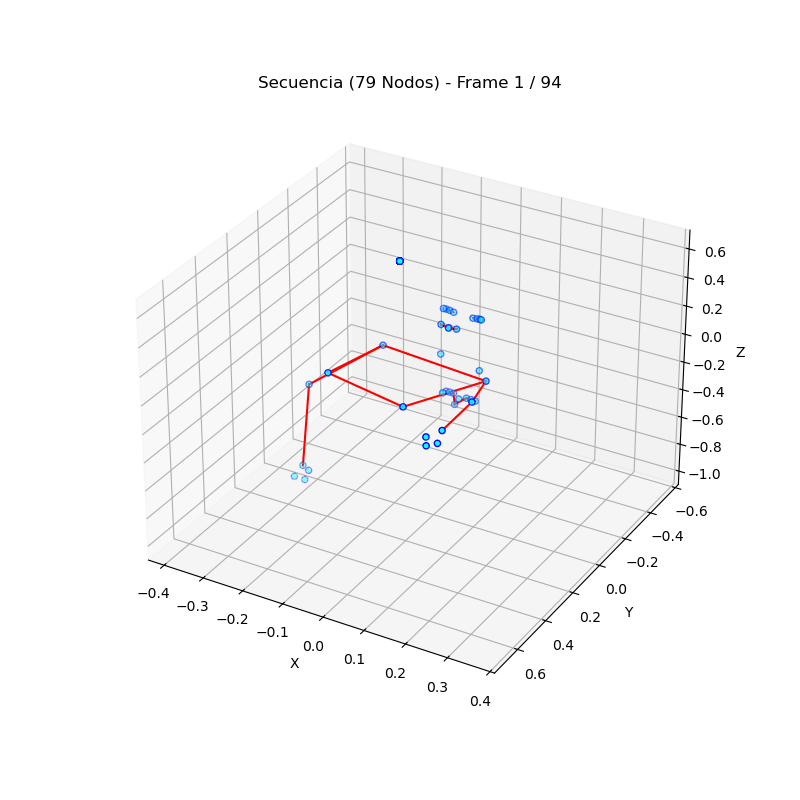

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display

# 1. Cargar tus datos (Asegúrate de apuntar a un .npy generado con tu nuevo script)
# Nota: La primera vez que lo corras, la dimensión debe imprimir (120, 79, 3)
data = np.load('/home/dracdarktime/Documents/Maestria/Semestre_II/Aprendizaje_Maquina/Manos/LSM/Dataset/sequences/jaja_20260525_143031_473.npy') 
print(f"Dimensiones del dataset: {data.shape}")

# --- DEFINIR LAS CONEXIONES DEL ESQUELETO (Adaptado para 79 nodos) ---
CONEXIONES = [
    # --- Pose (0 a 24) ---
    # Torso (hasta la cadera)
    (11, 12), (11, 23), (12, 24), (23, 24),
    # Brazos
    (11, 13), (13, 15), (12, 14), (14, 16),
    # Rostro básico (Ojos, Nariz)
    (0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6),
]

# --- Mano Izquierda (25 a 45) ---
o_izq = 25
CONEXIONES += [
    (o_izq, o_izq+1), (o_izq+1, o_izq+2), (o_izq+2, o_izq+3), (o_izq+3, o_izq+4),       # Pulgar
    (o_izq, o_izq+5), (o_izq+5, o_izq+6), (o_izq+6, o_izq+7), (o_izq+7, o_izq+8),       # Índice
    (o_izq, o_izq+9), (o_izq+9, o_izq+10), (o_izq+10, o_izq+11), (o_izq+11, o_izq+12),  # Medio
    (o_izq, o_izq+13), (o_izq+13, o_izq+14), (o_izq+14, o_izq+15), (o_izq+15, o_izq+16),# Anular
    (o_izq, o_izq+17), (o_izq+17, o_izq+18), (o_izq+18, o_izq+19), (o_izq+19, o_izq+20) # Meñique
]

# --- Mano Derecha (46 a 66) ---
o_der = 46
CONEXIONES += [
    (o_der, o_der+1), (o_der+1, o_der+2), (o_der+2, o_der+3), (o_der+3, o_der+4),       # Pulgar
    (o_der, o_der+5), (o_der+5, o_der+6), (o_der+6, o_der+7), (o_der+7, o_der+8),       # Índice
    (o_der, o_der+9), (o_der+9, o_der+10), (o_der+10, o_der+11), (o_der+11, o_der+12),  # Medio
    (o_der, o_der+13), (o_der+13, o_der+14), (o_der+14, o_der+15), (o_der+15, o_der+16),# Anular
    (o_der, o_der+17), (o_der+17, o_der+18), (o_der+18, o_der+19), (o_der+19, o_der+20) # Meñique
]

# --- Cejas y Boca ---
# Ceja Izquierda (67 a 70) -> Conectamos los 4 puntos en línea
c_izq = 67
CONEXIONES += [(c_izq, c_izq+1), (c_izq+1, c_izq+2), (c_izq+2, c_izq+3)]

# Ceja Derecha (71 a 74) -> Conectamos los 4 puntos en línea
c_der = 71
CONEXIONES += [(c_der, c_der+1), (c_der+1, c_der+2), (c_der+2, c_der+3)]

# Boca (75 a 78) -> Orden original MOUTH_IDS: [13 (sup), 14 (inf), 61 (comisura izq), 291 (comisura der)]
# En nuestro array son: 75 (sup), 76 (inf), 77 (izq), 78 (der)
# Conectamos las comisuras con los labios superior e inferior para formar un rombo
CONEXIONES += [
    (77, 75), # Comisura izq a Labio superior
    (75, 78), # Labio superior a Comisura der
    (78, 76), # Comisura der a Labio inferior
    (76, 77), # Labio inferior a Comisura izq
    (75, 76)  # Línea vertical para ver la apertura clara (opcional, pero útil)
]

# Filtro de seguridad: evitar errores por si acaso
CONEXIONES = [(i, j) for i, j in CONEXIONES if i < 79 and j < 79]

# 2. Configurar el lienzo 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Calcular límites para mantener la escala
x_min, x_max = data[:, :, 0].min(), data[:, :, 0].max()
y_min, y_max = data[:, :, 1].min(), data[:, :, 1].max()
z_min, z_max = data[:, :, 2].min(), data[:, :, 2].max()

# Margen pequeño
margin = 0.1
ax.set_xlim([x_min - margin, x_max + margin])
ax.set_ylim([y_min - margin, y_max + margin])
ax.set_zlim([z_min - margin, z_max + margin])

ax.invert_yaxis()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Estilo de puntos y líneas
scatter = ax.scatter([], [], [], c='cyan', marker='o', edgecolors='blue', s=20)
lineas = [ax.plot([], [], [], color='red', linewidth=1.5)[0] for _ in CONEXIONES]

# 3. Función que actualiza los puntos
def update(frame):
    ax.set_title(f"Secuencia (79 Nodos) - Frame {frame + 1} / {data.shape[0]}")
    
    x = data[frame, :, 0]
    y = data[frame, :, 1]
    z = data[frame, :, 2]
    
    scatter._offsets3d = (x, y, z)
    
    for linea, (i, j) in zip(lineas, CONEXIONES):
        linea.set_data([x[i], x[j]], [y[i], y[j]])
        linea.set_3d_properties([z[i], z[j]])
        
    return [scatter] + lineas

# 4. Generar animación
# Como ahora grabas a 30 FPS, el intervalo correcto es ~33 ms (1000ms / 30)
fps_deseado = 30
ani = FuncAnimation(fig, update, frames=data.shape[0], interval=1000/fps_deseado, blit=False)

# 5. Guardar como GIF
nombre_gif = 'secuencia_nueva_79nodos.gif'
ani.save(nombre_gif, writer='pillow', fps=fps_deseado)

plt.close()
print(f"¡Archivo '{nombre_gif}' guardado con éxito!")

display(Image(filename=nombre_gif))